In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Librerie PGMpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

# Librerie per la Visualizzazione
import networkx as nx
import matplotlib.pyplot as plt

print("Librerie PGMpy e supporto caricate con successo.")

Librerie PGMpy e supporto caricate con successo.


In [2]:
# Definisci il percorso dove è stato salvato il file CSV
# (Assumendo che sia in '../processed_data/' come da script precedente)
PROCESSED_DATA_PATH = Path('../processed_data') 

# --- NOME FILE CONFERMATO ---
INPUT_FILE = PROCESSED_DATA_PATH / 'atp_matches_discretized.csv'

try:
    df_pgm = pd.read_csv(INPUT_FILE)
    
    # FONDAMENTALE: Riconverti tutte le colonne a tipo 'category' per pgmpy
    for col in df_pgm.columns:
        df_pgm[col] = df_pgm[col].astype('category')
        
    print(f"Dati caricati e convertiti in 'category': {len(df_pgm)} righe.")
    print("DataFrame pronto per la modellazione PGM.")
    print("\nNodi disponibili (colonne):")
    print(list(df_pgm.columns))
    
except FileNotFoundError:
    print(f"ERRORE: Impossibile trovare il file CSV. Assicurati che '{INPUT_FILE.resolve()}' esista.")

Dati caricati e convertiti in 'category': 28724 righe.
DataFrame pronto per la modellazione PGM.

Nodi disponibili (colonne):
['Superficie', 'Tourney_Level', 'Cat_Rank', 'Cat_Age', 'Cat_Ht', 'Fav_Hand', 'Hand_Matchup', 'Cat_Ace', 'Cat_DF', 'Cat_ServiceWinPerc', 'Risultato_Favorevole']


In [3]:
# FASE 4.1: Definizione della Struttura del Grafo
print("Definizione della Struttura del Modello (Baseline Network)...")

# Creiamo un modello Bayesiano
model_atp = DiscreteBayesianNetwork()

# Aggiungiamo tutti gli 11 nodi (questo carica 'Fav_Hand' correttamente)
model_atp.add_nodes_from(df_pgm.columns)

# Aggiungiamo gli Archi (Edges) - La nostra ipotesi di struttura logica
print("Aggiunta archi (dipendenze)...")

# 1. Contesto e Caratteristiche -> Performance/Status
model_atp.add_edges_from([
    ('Superficie', 'Cat_Ace'),
    ('Superficie', 'Cat_DF'),
    ('Superficie', 'Cat_ServiceWinPerc'),
    ('Cat_Ht', 'Cat_Ace'), 
    ('Cat_Age', 'Cat_Rank'), 
    ('Fav_Hand', 'Hand_Matchup') # <-- CORREZIONE QUI
])

# 2. Tutti i Nodi -> Risultato_Favorevole
# (Questa lista 'predittori' era già corretta)
predittori = [
    'Superficie', 'Tourney_Level', 'Cat_Rank', 'Cat_Age', 'Cat_Ht', 
    'Fav_Hand', 'Hand_Matchup', 'Cat_Ace', 'Cat_DF', 'Cat_ServiceWinPerc'
]

for nodo_predittore in predittori:
    model_atp.add_edge(nodo_predittore, 'Risultato_Favorevole')
    
print(f"\nStruttura definita: {len(model_atp.nodes())} Nodi, {len(model_atp.edges())} Archi.")

Definizione della Struttura del Modello (Baseline Network)...
Aggiunta archi (dipendenze)...

Struttura definita: 11 Nodi, 16 Archi.


In [4]:
# Cella 4 - Apprendimento (Codice CORRETTO)

# FASE 4.2: Apprendimento (Fitting) del Modello
print("Inizio apprendimento (Fitting) delle Tabelle di Probabilità Condizionale (CPD)...")

model_atp.fit(data=df_pgm, estimator=MaximumLikelihoodEstimator)

print("Apprendimento completato.")

# --- CORREZIONE QUI ---
# SPOSTA IL CHECK QUI (DOPO IL FIT)
# Ora che il modello è "fittato", il check funzionerà.
print("Verifica del modello completo (con CPD)...")
if model_atp.check_model():
    print(f"\nModello creato e verificato con successo: {len(model_atp.nodes())} Nodi, {len(model_atp.edges())} Archi.")
else:
    print("\nATTENZIONE: Il modello ha fallito il check_model() dopo il fit.")
# --- FINE CORREZIONE ---


# Verifica (Opzionale): Controlliamo una delle CPD
print("\nEsempio di CPD per 'Cat_Ace' (dipende da Superficie e Cat_Ht):")
cpd_ace = model_atp.get_cpds('Cat_Ace')
print(cpd_ace)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}


Inizio apprendimento (Fitting) delle Tabelle di Probabilità Condizionale (CPD)...
Apprendimento completato.
Verifica del modello completo (con CPD)...

Modello creato e verificato con successo: 11 Nodi, 16 Archi.

Esempio di CPD per 'Cat_Ace' (dipende da Superficie e Cat_Ht):
+--------------------+-----+---------------------+
| Cat_Ht             | ... | Cat_Ht(Superiore)   |
+--------------------+-----+---------------------+
| Superficie         | ... | Superficie(Hard)    |
+--------------------+-----+---------------------+
| Cat_Ace(Inferiore) | ... | 0.19276144771045792 |
+--------------------+-----+---------------------+
| Cat_Ace(Medio)     | ... | 0.21015796840631873 |
+--------------------+-----+---------------------+
| Cat_Ace(Superiore) | ... | 0.5970805838832234  |
+--------------------+-----+---------------------+


Disegno del grafo della Rete Bayesiana...


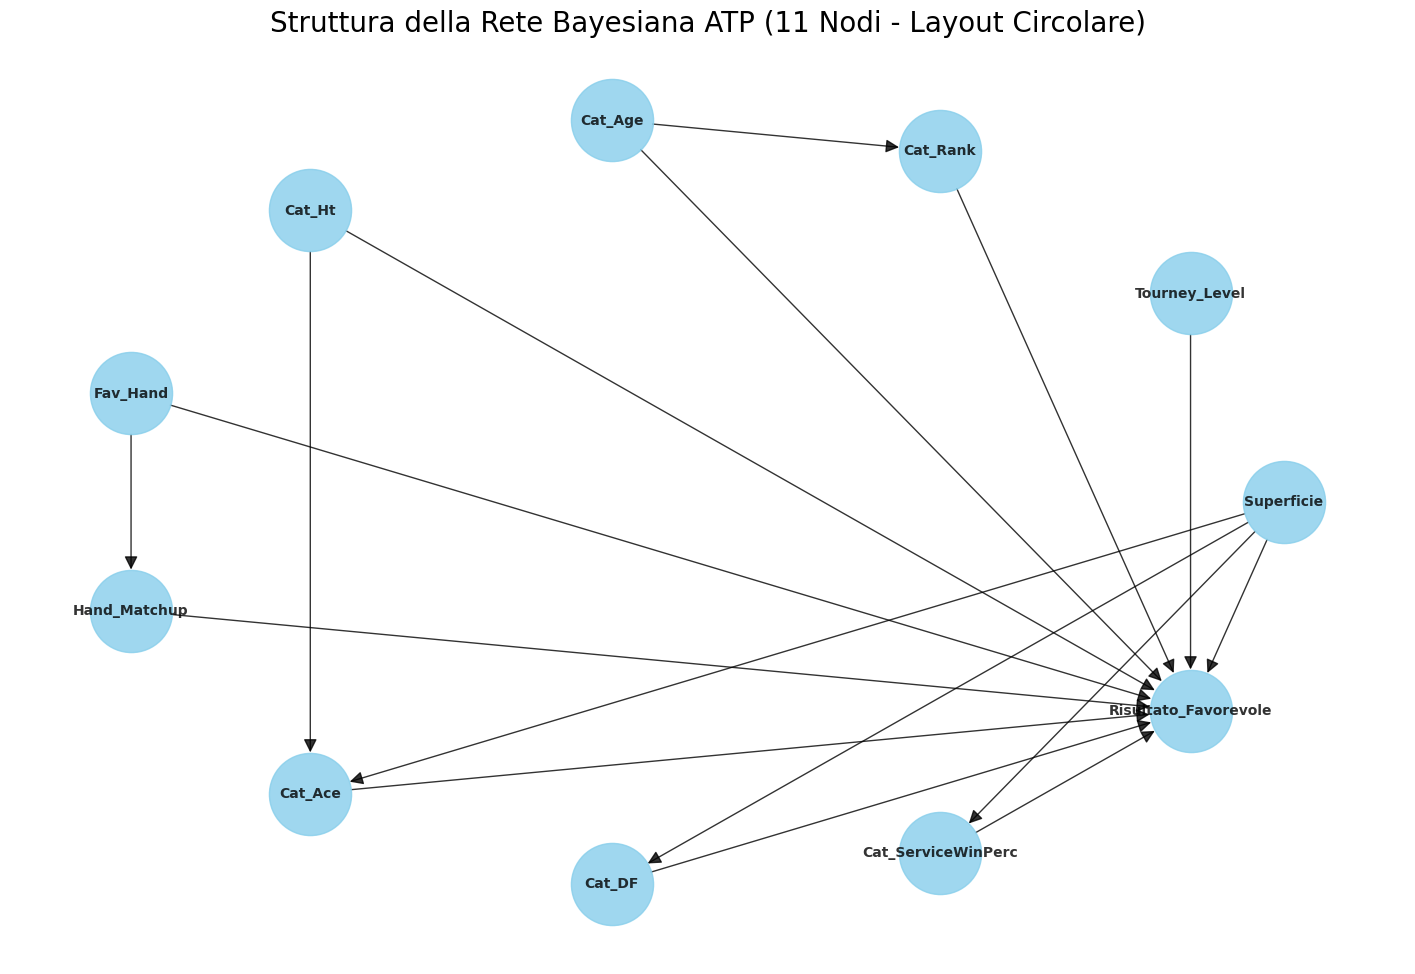

In [5]:
# FASE 4.3: Visualizzazione del Grafo
print("Disegno del grafo della Rete Bayesiana...")

plt.figure(figsize=(18, 12)) 

# --- CORREZIONE QUI ---
# Abbiamo sostituito 'nx.spring_layout' (che causa il bug 'StopIteration')
# con 'nx.circular_layout' (che è stabile).
pos = nx.circular_layout(model_atp) 
# --- FINE CORREZIONE ---

nx.draw_networkx(
    model_atp,
    pos=pos,
    with_labels=True,      
    node_size=3500,        
    node_color='skyblue',  
    font_size=10,
    font_weight='bold',
    arrowsize=20,          
    alpha=0.8
)

plt.title('Struttura della Rete Bayesiana ATP (11 Nodi - Layout Circolare)', fontsize=20)
plt.axis('off') 
plt.show()

In [6]:
# FASE 5: Inferenza
print("Inizializzazione del motore di Inferenza (VariableElimination)...")

# Creiamo l'oggetto per fare inferenza sul modello addestrato
inference = VariableElimination(model_atp)

# --- Esempio di Query 1: Upset su Erba ---
# Domanda: "Qual è la probabilità di un Upset (Sconfitta) su Erba, 
#           in un match Equilibrato?"
print("\nQuery 1: Probabilità di Risultato (Upset) su Erba vs Rank Equilibrato:")

query_upset = inference.query(
    variables=['Risultato_Favorevole'],   # Cosa vogliamo sapere
    evidence={                            # Cosa sappiamo (le condizioni)
        'Superficie': 'Grass',
        'Cat_Rank': 'Equilibrato'
    }
)
print(query_upset)


# --- Esempio di Query 2: Impatto dell'Altezza ---
# Domanda: "Qual è la probabilità che il favorito faccia Ace (Superiore) 
#           se è Alto e gioca su Erba?"
print("\nQuery 2: Probabilità di Ace (Cat_Ace) se Alto e su Erba:")

query_ace = inference.query(
    variables=['Cat_Ace'],                # Cosa vogliamo sapere
    evidence={                            # Cosa sappiamo
        'Superficie': 'Grass',
        'Cat_Ht': 'Superiore' # 'Superiore' corrisponde al bin degli 'Alti'
    }
)
print(query_ace)

Inizializzazione del motore di Inferenza (VariableElimination)...

Query 1: Probabilità di Risultato (Upset) su Erba vs Rank Equilibrato:
+---------------------------------+-----------------------------+
| Risultato_Favorevole            |   phi(Risultato_Favorevole) |
+=================================+=============================+
| Risultato_Favorevole(Sconfitta) |                      0.4651 |
+---------------------------------+-----------------------------+
| Risultato_Favorevole(Vittoria)  |                      0.5349 |
+---------------------------------+-----------------------------+

Query 2: Probabilità di Ace (Cat_Ace) se Alto e su Erba:
+--------------------+----------------+
| Cat_Ace            |   phi(Cat_Ace) |
+====================+================+
| Cat_Ace(Inferiore) |         0.1841 |
+--------------------+----------------+
| Cat_Ace(Medio)     |         0.1891 |
+--------------------+----------------+
| Cat_Ace(Superiore) |         0.6269 |
+--------------------+

In [7]:
# FASE 4.1 (Alternativa): Definizione della Struttura 2 (Naive Bayes)
print("Definizione della Struttura del Modello 2 (Naive Bayes)...")

# Creiamo il secondo modello
model_atp_naive = DiscreteBayesianNetwork()

# Aggiungiamo tutti gli 11 nodi
model_atp_naive.add_nodes_from(df_pgm.columns)

# Aggiungiamo gli Archi (Edges)
# Nella Naive Bayes, tutti i predittori puntano solo al target
print("Aggiunta archi (dipendenze Naive Bayes)...")

predittori = [
    'Superficie', 'Tourney_Level', 'Cat_Rank', 'Cat_Age', 'Cat_Ht', 
    'Fav_Hand', 'Hand_Matchup', 'Cat_Ace', 'Cat_DF', 'Cat_ServiceWinPerc'
]

for nodo_predittore in predittori:
    model_atp_naive.add_edge(nodo_predittore, 'Risultato_Favorevole')
    
print(f"\nStruttura Naive Bayes definita: {len(model_atp_naive.nodes())} Nodi, {len(model_atp_naive.edges())} Archi.")

Definizione della Struttura del Modello 2 (Naive Bayes)...
Aggiunta archi (dipendenze Naive Bayes)...

Struttura Naive Bayes definita: 11 Nodi, 10 Archi.


In [8]:
# FASE 4.2 (Alternativa): Apprendimento (Fitting) del Modello 2
print("Inizio apprendimento (Fitting) delle CPD per il modello Naive Bayes...")

# Usiamo lo stesso estimator
model_atp_naive.fit(data=df_pgm, estimator=MaximumLikelihoodEstimator)

print("Apprendimento Naive Bayes completato.")

# Verifichiamo il modello dopo il fit
print("Verifica del modello Naive Bayes...")
if model_atp_naive.check_model():
    print("Modello Naive Bayes creato e verificato con successo.")
else:
    print("ATTENZIONE: Il modello Naive Bayes ha fallito il check_model().")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}


Inizio apprendimento (Fitting) delle CPD per il modello Naive Bayes...
Apprendimento Naive Bayes completato.
Verifica del modello Naive Bayes...
Modello Naive Bayes creato e verificato con successo.


Disegno del grafo della Rete Naive Bayes...


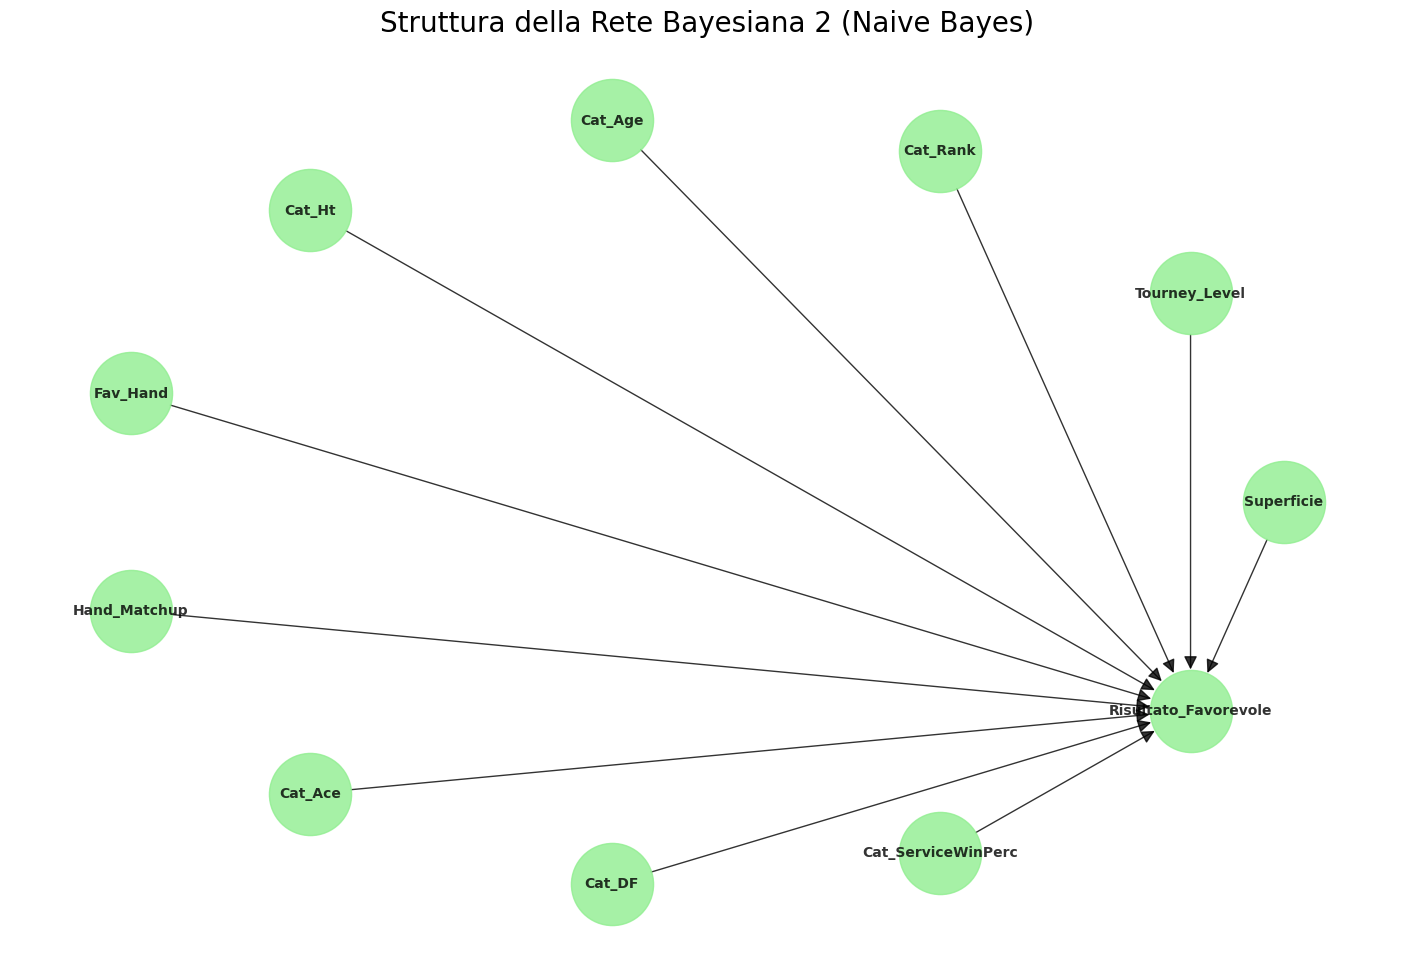

In [9]:
# FASE 4.3 (Alternativa): Visualizzazione del Grafo 2
print("Disegno del grafo della Rete Naive Bayes...")

plt.figure(figsize=(18, 12)) 

# Usiamo un layout 'circular' per coerenza e per evitare il bug
pos_naive = nx.circular_layout(model_atp_naive) 

nx.draw_networkx(
    model_atp_naive,
    pos=pos_naive,
    with_labels=True,      
    node_size=3500,        
    node_color='lightgreen',  # Colore diverso per distinguerlo
    font_size=10,
    font_weight='bold',
    arrowsize=20,          
    alpha=0.8
)

plt.title('Struttura della Rete Bayesiana 2 (Naive Bayes)', fontsize=20)
plt.axis('off') 
plt.show()

In [10]:
# FASE 5 (Confronto): Inferenza sui due Modelli
print("Inizializzazione del motore di Inferenza per Naive Bayes...")

inference_naive = VariableElimination(model_atp_naive)

# --- CONFRONTO QUERY 1: Upset su Erba ---
print("\n--- Confronto Query 1: Probabilità Upset (Sconfitta) su Erba, Rank Equilibrato ---")

# Risultato Modello 1 (Complesso) - (già calcolato nella Cella 6, lo ricalcoliamo per confronto)
query_upset_complesso = inference.query(
    variables=['Risultato_Favorevole'],
    evidence={'Superficie': 'Grass', 'Cat_Rank': 'Equilibrato'}
)
print("\n[Modello 1 - Complesso]:")
print(query_upset_complesso)

# Risultato Modello 2 (Naive Bayes)
query_upset_naive = inference_naive.query(
    variables=['Risultato_Favorevole'],
    evidence={'Superficie': 'Grass', 'Cat_Rank': 'Equilibrato'}
)
print("\n[Modello 2 - Naive Bayes]:")
print(query_upset_naive)

# --- CONFRONTO QUERY 2: Impatto dell'Altezza ---
print("\n--- Confronto Query 2: Probabilità Ace (Superiore) se Alto e su Erba ---")

# Risultato Modello 1 (Complesso)
query_ace_complesso = inference.query(
    variables=['Cat_Ace'],
    evidence={'Superficie': 'Grass', 'Cat_Ht': 'Superiore'}
)
print("\n[Modello 1 - Complesso]:")
print(query_ace_complesso)

# Risultato Modello 2 (Naive Bayes)
# NOTA: Questa query darà un risultato "strano"
query_ace_naive = inference_naive.query(
    variables=['Cat_Ace'],
    evidence={'Superficie': 'Grass', 'Cat_Ht': 'Superiore'}
)
print("\n[Modello 2 - Naive Bayes]:")
print(query_ace_naive)

Inizializzazione del motore di Inferenza per Naive Bayes...

--- Confronto Query 1: Probabilità Upset (Sconfitta) su Erba, Rank Equilibrato ---

[Modello 1 - Complesso]:
+---------------------------------+-----------------------------+
| Risultato_Favorevole            |   phi(Risultato_Favorevole) |
+=================================+=============================+
| Risultato_Favorevole(Sconfitta) |                      0.4651 |
+---------------------------------+-----------------------------+
| Risultato_Favorevole(Vittoria)  |                      0.5349 |
+---------------------------------+-----------------------------+

[Modello 2 - Naive Bayes]:
+---------------------------------+-----------------------------+
| Risultato_Favorevole            |   phi(Risultato_Favorevole) |
+=================================+=============================+
| Risultato_Favorevole(Sconfitta) |                      0.4755 |
+---------------------------------+-----------------------------+
| Risultat

In [11]:
# FASE 4.1 (Alternativa): Definizione della Struttura 3 (Complesso - Senza Ht->Ace)
print("Definizione della Struttura del Modello 3 (Complesso - Senza Ht->Ace)...")

model_atp_no_ht_ace = DiscreteBayesianNetwork()
model_atp_no_ht_ace.add_nodes_from(df_pgm.columns)

print("Aggiunta archi (dipendenze Modello 3)...")

# Archi quasi identici al Modello 1, ma SENZA ('Cat_Ht', 'Cat_Ace')
model_atp_no_ht_ace.add_edges_from([
    ('Superficie', 'Cat_Ace'),
    ('Superficie', 'Cat_DF'),
    ('Superficie', 'Cat_ServiceWinPerc'),
    # ('Cat_Ht', 'Cat_Ace'), # <-- ARCO RIMOSSO QUI!
    ('Cat_Age', 'Cat_Rank'), 
    ('Fav_Hand', 'Hand_Matchup') 
])

predittori = [
    'Superficie', 'Tourney_Level', 'Cat_Rank', 'Cat_Age', 'Cat_Ht', 
    'Fav_Hand', 'Hand_Matchup', 'Cat_Ace', 'Cat_DF', 'Cat_ServiceWinPerc'
]

for nodo_predittore in predittori:
    model_atp_no_ht_ace.add_edge(nodo_predittore, 'Risultato_Favorevole')
    
print(f"\nStruttura Modello 3 definita: {len(model_atp_no_ht_ace.nodes())} Nodi, {len(model_atp_no_ht_ace.edges())} Archi.")

Definizione della Struttura del Modello 3 (Complesso - Senza Ht->Ace)...
Aggiunta archi (dipendenze Modello 3)...

Struttura Modello 3 definita: 11 Nodi, 15 Archi.


In [12]:
# FASE 4.2 (Alternativa): Apprendimento (Fitting) del Modello 3
print("Inizio apprendimento (Fitting) delle CPD per il Modello 3...")

model_atp_no_ht_ace.fit(data=df_pgm, estimator=MaximumLikelihoodEstimator)

print("Apprendimento Modello 3 completato.")

print("Verifica del Modello 3...")
if model_atp_no_ht_ace.check_model():
    print("Modello 3 creato e verificato con successo.")
else:
    print("ATTENZIONE: Il Modello 3 ha fallito il check_model().")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}


Inizio apprendimento (Fitting) delle CPD per il Modello 3...
Apprendimento Modello 3 completato.
Verifica del Modello 3...
Modello 3 creato e verificato con successo.


Disegno del grafo della Rete Bayesiana 3 (Senza Ht->Ace)...


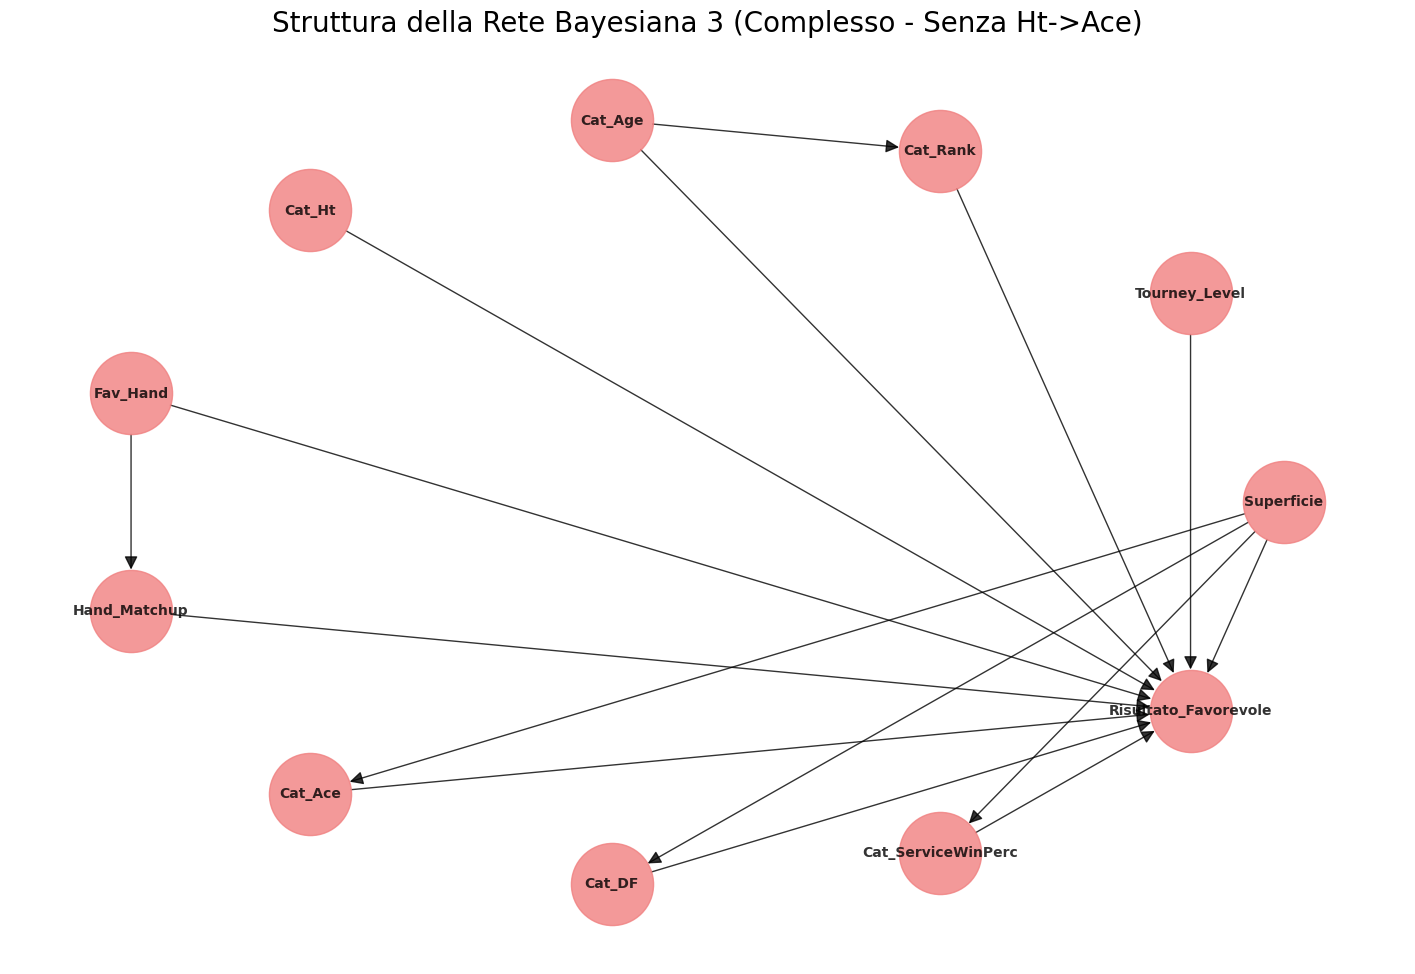

In [13]:
# FASE 4.3 (Alternativa): Visualizzazione del Grafo 3
print("Disegno del grafo della Rete Bayesiana 3 (Senza Ht->Ace)...")

plt.figure(figsize=(18, 12)) 

pos_no_ht_ace = nx.circular_layout(model_atp_no_ht_ace) 

nx.draw_networkx(
    model_atp_no_ht_ace,
    pos=pos_no_ht_ace,
    with_labels=True,      
    node_size=3500,        
    node_color='lightcoral',  # Un altro colore per distinguerlo
    font_size=10,
    font_weight='bold',
    arrowsize=20,          
    alpha=0.8
)

plt.title('Struttura della Rete Bayesiana 3 (Complesso - Senza Ht->Ace)', fontsize=20)
plt.axis('off') 
plt.show()

In [14]:
# --- CORREZIONE: Importa le classi dai moduli corretti ---
from pgmpy.estimators import HillClimbSearch

# Il file è StructureScore.py e la classe si chiama BDeu (non BdeuScore)
from pgmpy.estimators.StructureScore import BDeu  # <-- NOME CLASSE CORRETTO
# -----------------------------------------------

# FASE 4.1 (Alternativa): Definizione della Struttura 4 (Appresa dai Dati)
print("Inizio apprendimento automatico della struttura del Modello 4 (Hill Climb Search)...")

# HillClimbSearch ora è importato
hc = HillClimbSearch(data=df_pgm) 

# L'algoritmo HillClimbSearch costruisce una rete che massimizza lo score
best_model_hc = hc.estimate(
    # --- CORREZIONE: Usa la classe BDeu ---
    scoring_method=BDeu(data=df_pgm), 
    max_iter=100,
    epsilon=1e-5
)

# Convertiamo la struttura appresa in un DiscreteBayesianNetwork
model_atp_learned = DiscreteBayesianNetwork(best_model_hc.edges())
model_atp_learned.add_nodes_from(df_pgm.columns) # Aggiungiamo tutti i nodi

print(f"\nStruttura Modello 4 (Appresa) definita: {len(model_atp_learned.nodes())} Nodi, {len(model_atp_learned.edges())} Archi.")

# Stampa gli archi scoperti dall'algoritmo
print("\nArchi scoperti da HillClimbSearch:")
print(model_atp_learned.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}


Inizio apprendimento automatico della struttura del Modello 4 (Hill Climb Search)...


  0%|          | 0/100 [00:00<?, ?it/s]


Struttura Modello 4 (Appresa) definita: 11 Nodi, 20 Archi.

Archi scoperti da HillClimbSearch:
[('Superficie', 'Cat_Ace'), ('Superficie', 'Fav_Hand'), ('Cat_Ace', 'Cat_Ht'), ('Cat_Ace', 'Cat_ServiceWinPerc'), ('Cat_Ace', 'Cat_DF'), ('Cat_Ace', 'Risultato_Favorevole'), ('Cat_Ace', 'Cat_Age'), ('Cat_Ace', 'Hand_Matchup'), ('Fav_Hand', 'Hand_Matchup'), ('Fav_Hand', 'Cat_Age'), ('Tourney_Level', 'Superficie'), ('Tourney_Level', 'Cat_Rank'), ('Tourney_Level', 'Cat_Ace'), ('Tourney_Level', 'Fav_Hand'), ('Cat_Ht', 'Cat_Age'), ('Cat_Ht', 'Fav_Hand'), ('Cat_ServiceWinPerc', 'Risultato_Favorevole'), ('Cat_ServiceWinPerc', 'Cat_DF'), ('Cat_ServiceWinPerc', 'Cat_Rank'), ('Risultato_Favorevole', 'Cat_Ht')]


In [15]:
# FASE 4.2 (Alternativa): Apprendimento (Fitting) del Modello 4
print("Inizio apprendimento (Fitting) delle CPD per il Modello 4 (Appreso)...")

model_atp_learned.fit(data=df_pgm, estimator=MaximumLikelihoodEstimator)

print("Apprendimento Modello 4 completato.")

print("Verifica del Modello 4...")
if model_atp_learned.check_model():
    print("Modello 4 creato e verificato con successo.")
else:
    print("ATTENZIONE: Il Modello 4 ha fallito il check_model().")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Superficie': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_ServiceWinPerc': 'C', 'Risultato_Favorevole': 'C'}


Inizio apprendimento (Fitting) delle CPD per il Modello 4 (Appreso)...
Apprendimento Modello 4 completato.
Verifica del Modello 4...
Modello 4 creato e verificato con successo.


Disegno del grafo della Rete Bayesiana 4 (Struttura Appresa)...


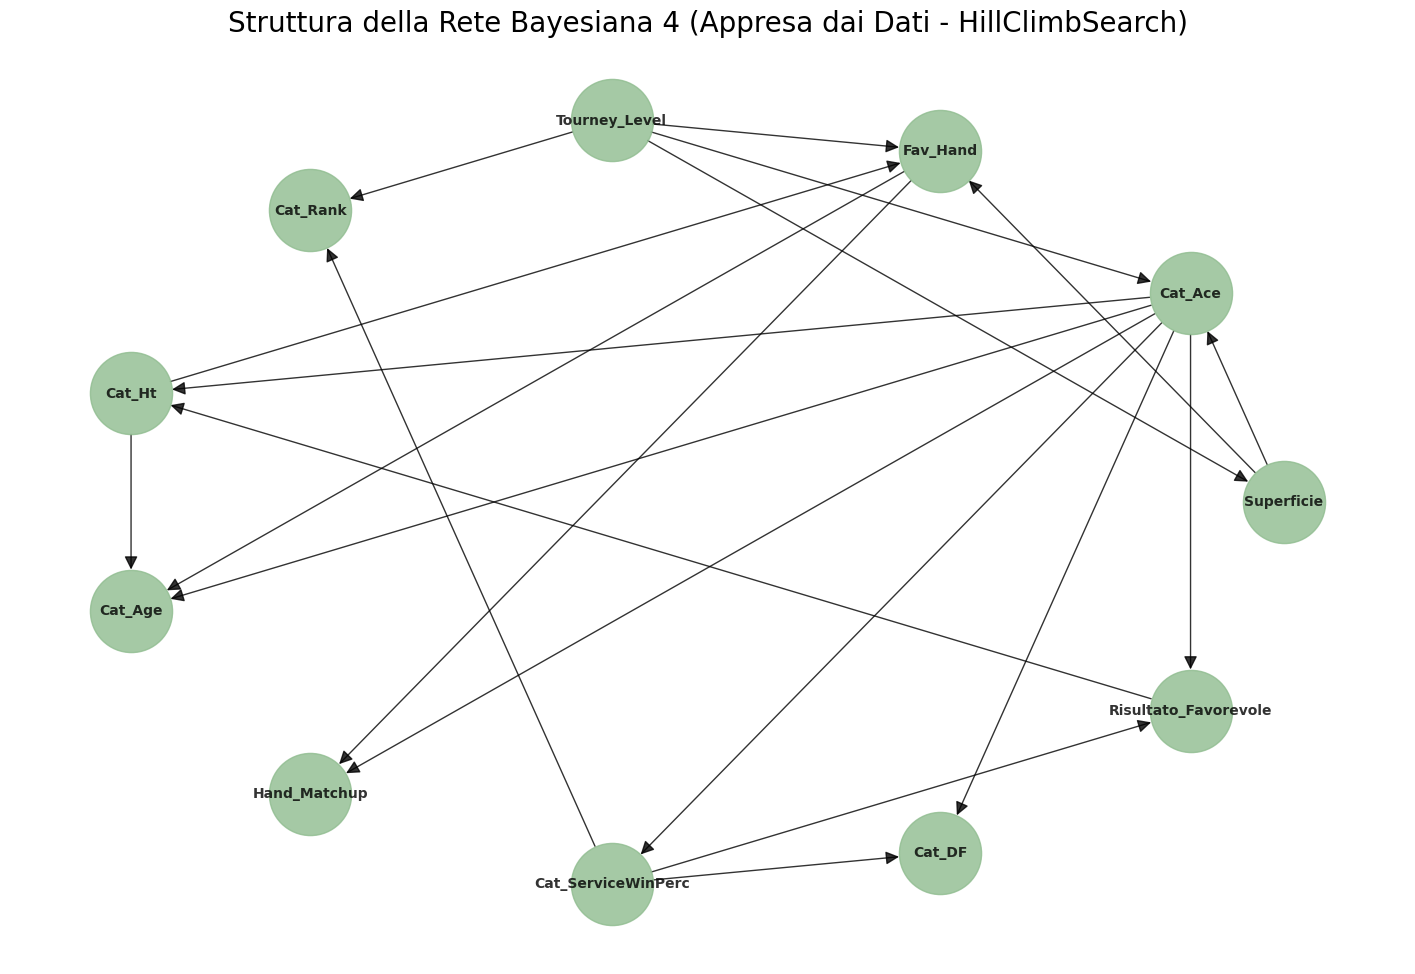

In [16]:
# FASE 4.3 (Alternativa): Visualizzazione del Grafo 4
print("Disegno del grafo della Rete Bayesiana 4 (Struttura Appresa)...")

plt.figure(figsize=(18, 12)) 

pos_learned = nx.circular_layout(model_atp_learned) 

nx.draw_networkx(
    model_atp_learned,
    pos=pos_learned,
    with_labels=True,      
    node_size=3500,        
    node_color='darkseagreen',  # Un altro colore
    font_size=10,
    font_weight='bold',
    arrowsize=20,          
    alpha=0.8
)

plt.title('Struttura della Rete Bayesiana 4 (Appresa dai Dati - HillClimbSearch)', fontsize=20)
plt.axis('off') 
plt.show()

In [22]:
# FASE 5: CONFRONTO FINALE DELLE INFERENZE

print("Inizializzazione dei motori di inferenza per TUTTI i modelli...")

# Inizializza tutti i 4 motori di inferenza
inference_m1 = VariableElimination(model_atp)
inference_m2 = VariableElimination(model_atp_naive)
inference_m3 = VariableElimination(model_atp_no_ht_ace)
inference_m4 = VariableElimination(model_atp_learned)

models_inference = [
    ("Modello 1 (Complesso)", inference_m1),
    ("Modello 2 (Naive Bayes)", inference_m2),
    ("Modello 3 (Senza Ht->Ace)", inference_m3),
    ("Modello 4 (Appreso)", inference_m4)
]

print("--- INIZIO CONFRONTO QUERY ---")

# ==============================================================================
# Query 1: P(Sconfitta | Superficie=Erba, Rank=Equilibrato)
# ==============================================================================
print("\n--- Query 1: P(Sconfitta | Superficie=Erba, Rank=Equilibrato) ---")
for name, infer in models_inference:
    result = infer.query(
        variables=['Risultato_Favorevole'],
        evidence={'Superficie': 'Grass', 'Cat_Rank': 'Equilibrato'}
    )
    prob_sconfitta = result.values[result.get_state_names('Risultato_Favorevole', 0).index('Sconfitta')]
    print(f"  [{name}]: {prob_sconfitta:.4f} ({prob_sconfitta*100:.1f}%)")

# ==============================================================================
# Query (Quella che ti dà errore)
# ==============================================================================
print("\n--- Query: P(Cat_Ace | Rank=Equilibrato, Matchup=Opposta) ---") # Ho inventato il titolo, adattalo al tuo Query 6, 7 ecc.

for name, infer in models_inference:
    result = infer.query(
        variables=['Cat_Ace'],
        evidence={
            'Cat_Rank': 'Equilibrato',
            'Hand_Matchup': 'Opposta'
        }
    )
    
    # --- VECCHIA RIGA CHE CAUSA L'ERRORE ---
    # state_index = result.get_state_names('Cat_Ace', 0).index('Superiore')
    
    # --- NUOVA SOLUZIONE PIÙ ROBUSTA ---
    # Accediamo all'elenco degli stati tramite l'attributo .state_names
    states_list = result.state_names['Cat_Ace']
    
    # Ora cerchiamo l'indice di 'Superiore' in questo elenco
    state_index = states_list.index('Superiore')
    
    # (Puoi anche de-commentare la riga qui sotto per vedere cosa stampa)
    # print(f"  Stati trovati per Cat_Ace: {states_list}")
    
    prob_ace_sup = result.values[state_index]
    print(f"  [{name}]: {prob_ace_sup:.4f} ({prob_ace_sup*100:.1f}%)")

# ==============================================================================
# Query 3: P(Service=Inferiore | Risultato=Sconfitta)
# ==============================================================================
print("\n--- Query 3: P(Service=Inferiore | Risultato=Sconfitta) ---")
for name, infer in models_inference:
    result = infer.query(
        variables=['Cat_ServiceWinPerc'],
        evidence={'Risultato_Favorevole': 'Sconfitta'}
    )
    state_index = result.get_state_names('Cat_ServiceWinPerc', 0).index('Inferiore')
    prob_serv_inf = result.values[state_index]
    print(f"  [{name}]: {prob_serv_inf:.4f} ({prob_serv_inf*100:.1f}%)")

# ==============================================================================
# Query 4: P(Sconfitta | Rank=FavoritoNetto, Service=Inferiore)
# ==============================================================================
print("\n--- Query 4: P(Sconfitta | Rank=FavoritoNetto, Service=Inferiore) ---")
for name, infer in models_inference:
    result = infer.query(
        variables=['Risultato_Favorevole'],
        evidence={'Cat_Rank': 'FavoritoNetto', 'Cat_ServiceWinPerc': 'Inferiore'}
    )
    prob_sconfitta = result.values[result.get_state_names('Risultato_Favorevole', 0).index('Sconfitta')]
    print(f"  [{name}]: {prob_sconfitta:.4f} ({prob_sconfitta*100:.1f}%)")

# ==============================================================================
# Query 5: P(Sconfitta | Rank=Equilibrato, Matchup=Opposta)
# ==============================================================================
print("\n--- Query 5: P(Sconfitta | Rank=Equilibrato, Matchup=Opposta) ---")
for name, infer in models_inference:
    result = infer.query(
        variables=['Risultato_Favorevole'],
        evidence={'Cat_Rank': 'Equilibrato', 'Hand_Matchup': 'Opposta'}
    )
    prob_sconfitta = result.values[result.get_state_names('Risultato_Favorevole', 0).index('Sconfitta')]
    print(f"  [{name}]: {prob_sconfitta:.4f} ({prob_sconfitta*100:.1f}%)")

Inizializzazione dei motori di inferenza per TUTTI i modelli...
--- INIZIO CONFRONTO QUERY ---

--- Query 1: P(Sconfitta | Superficie=Erba, Rank=Equilibrato) ---
  [Modello 1 (Complesso)]: 0.4651 (46.5%)
  [Modello 2 (Naive Bayes)]: 0.4755 (47.6%)
  [Modello 3 (Senza Ht->Ace)]: 0.4675 (46.7%)
  [Modello 4 (Appreso)]: 0.4463 (44.6%)

--- Query: P(Cat_Ace | Rank=Equilibrato, Matchup=Opposta) ---
  [Modello 1 (Complesso)]: 0.3161 (31.6%)
  [Modello 2 (Naive Bayes)]: 0.3175 (31.7%)
  [Modello 3 (Senza Ht->Ace)]: 0.3175 (31.7%)
  [Modello 4 (Appreso)]: 0.2916 (29.2%)

--- Query 3: P(Service=Inferiore | Risultato=Sconfitta) ---
  [Modello 1 (Complesso)]: 0.6882 (68.8%)
  [Modello 2 (Naive Bayes)]: 0.6440 (64.4%)
  [Modello 3 (Senza Ht->Ace)]: 0.6767 (67.7%)
  [Modello 4 (Appreso)]: 0.8585 (85.9%)

--- Query 4: P(Sconfitta | Rank=FavoritoNetto, Service=Inferiore) ---
  [Modello 1 (Complesso)]: 0.7887 (78.9%)
  [Modello 2 (Naive Bayes)]: 0.7638 (76.4%)
  [Modello 3 (Senza Ht->Ace)]: 0.7834 (78

In [1]:
# ==============================================================================
# ANALISI APPROFONDITA: L'IMPATTO DELLA SUPERFICIE
# ==============================================================================

surfaces = ['Clay', 'Hard', 'Grass']

# --- Query A: Probabilità di fare molti ACE (Cat_Ace='Superiore') ---
# Scenario: Giocatore Alto (che di solito fa ace), Rank Favorito
print("\n--- Query A: Impatto Superficie su ACE (Giocatore Alto) ---")
print(f"{'Modello':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
print("-" * 65)

for name, infer in models_inference:
    probs = []
    for surf in surfaces:
        try:
            q = infer.query(
                variables=['Cat_Ace'],
                evidence={
                    'Superficie': surf,
                    'Cat_Ht': 'Superiore', # Giocatore alto
                    'Cat_Rank': 'FavoritoNetto'
                },
                show_progress=False
            )
            # Cerchiamo la probabilità di Ace 'Superiore'
            # Usa .state_names per sicurezza
            idx = q.state_names['Cat_Ace'].index('Superiore')
            probs.append(q.values[idx])
        except:
            probs.append(0.0) # Gestione errori se mancano stati
            
    print(f"{name:<25} | {probs[0]:.4f}     | {probs[1]:.4f}     | {probs[2]:.4f}")


# --- Query B: Probabilità di tenere il SERVIZIO (Cat_ServiceWinPerc='Superiore') ---
# Scenario: Match Equilibrato
print("\n--- Query B: Impatto Superficie su SERVIZIO (Match Equilibrato) ---")
print(f"{'Modello':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
print("-" * 65)

for name, infer in models_inference:
    probs = []
    for surf in surfaces:
        try:
            q = infer.query(
                variables=['Cat_ServiceWinPerc'],
                evidence={
                    'Superficie': surf,
                    'Cat_Rank': 'Equilibrato'
                },
                show_progress=False
            )
            # Cerchiamo la probabilità di ServiceWin 'Superiore'
            idx = q.state_names['Cat_ServiceWinPerc'].index('Superiore')
            probs.append(q.values[idx])
        except:
            probs.append(0.0)
            
    print(f"{name:<25} | {probs[0]:.4f}     | {probs[1]:.4f}     | {probs[2]:.4f}")


# --- Query C: Rischio SCONFITTA per un Favorito Netto ---
# Scenario: Favorito Netto gioca contro mano opposta
print("\n--- Query C: Rischio SCONFITTA per Favorito (Upset) per Superficie ---")
print(f"{'Modello':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
print("-" * 65)

for name, infer in models_inference:
    probs = []
    for surf in surfaces:
        try:
            q = infer.query(
                variables=['Risultato_Favorevole'],
                evidence={
                    'Superficie': surf,
                    'Cat_Rank': 'FavoritoNetto',
                    'Hand_Matchup': 'Opposta'
                },
                show_progress=False
            )
            # Cerchiamo la probabilità di 'Sconfitta'
            idx = q.state_names['Risultato_Favorevole'].index('Sconfitta')
            probs.append(q.values[idx])
        except:
            probs.append(0.0)
            
    print(f"{name:<25} | {probs[0]:.4f}     | {probs[1]:.4f}     | {probs[2]:.4f}")


--- Query A: Impatto Superficie su ACE (Giocatore Alto) ---
Modello                   | Clay       | Hard       | Grass     
-----------------------------------------------------------------


NameError: name 'models_inference' is not defined